# EX09: Data Analysis for Continuous Improvement

In this exercise, you and your partner will be defining functions for data analysis, using those functions to analyze the data from the anonymized survey you took not long ago, and then presenting your analysis via a live website! Your project will need to satisfy many specifications so be sure to read the entire write-up and this template notebook thoroughly before beginning any programming.

In [47]:
__author__ = ["", ""] # Record you and your partner's PIDs here!

### IMPORTANT SETUP STEP

To ensure the correct version of python is being used while you are running this Jupyter notebook, please first make sure you are in the dev container (the bottom left corner should say Dev Container). Then, click on the kernel selection button (the rightmost button at the top of this file), it may currently say "Select Kernel", "Python 3.12.4", or something similar. 

If your kernel selection button says "Select Kernel", after clicking on it there should be two options: "Python Environments..." and "Existing Jupyter Server...". Choose "Python Environments...", then there should be two options (but possibly more will show up): "Python 3.12.4 `/usr/local/bin/python`" and "Python 3.12.4 `/usr/bin/python3`". Please select the first of these two options, and if any others are present do not select them. 

If your kernel selection button says anything besides "Select Kernel", after clicking on it it will tell you which you have currently selected. If it is not the "Python 3.12.4 `/usr/local/bin/python`" option, choose "Select Another Kernel..." and then follow the previous paragraph's instructions. If your kernel selection menu does not include the necessary options to follow these instructions, please come to office hours.

## Part 0: Data Utilities

You will define and use functions that are commonly useful when _wrangling_ data in this exercise. You will frequently need your data to be organized in specific ways in order to perform analysis on it and that organization is rarely exactly the "shape" the data is stored in (such as a CSV table). Data _wrangling_ is the process of loading, converting, and reorganizing data so that you can analyze it.

You will implement the utility functions for this exercise in the `data_utils.py` file found in the `exercises/ex09` directory. As you now know, when you import modules in a running Python program, the module is evaluated only once. Since your Jupyter Notebook _kernel_ is running the entire time you are working on functions in `data_utils.py`, we will use a special extension to automatically reload any changes you make _and save_ in modules you import. The special conventions in the cell below are turning this feature on.

In [48]:
%reload_ext autoreload
%autoreload 2
print("Autoreload of imported modules enabled. Be sure to save your work in other modules!")

Autoreload of imported modules enabled. Be sure to save your work in other modules!


The data files you will use in this exercise, `survey_izzi.csv` and `survey_alyssa.csv`, are located in the `exercises/ex09/data` directory. We will establish a constant to hold these filenames for later.

Each row represents an individual survey response. Each column has a description which can be found on the project write-up here: <https://26s-comp110.github.io/exercises/ex09_data_analysis.html>

In [49]:
DATA_FILE_DIRECTORY: str = "data/"
DATA_FILE_NAMES: list[str] = ["survey_izzi.csv", "survey_alyssa.csv"]
DATA_FILE_NAME_IZZI: str = f"{DATA_FILE_DIRECTORY}{DATA_FILE_NAMES[0]}"
DATA_FILE_NAME_ALYSSA: str = f"{DATA_FILE_DIRECTORY}{DATA_FILE_NAMES[1]}"

### Part 0.0: Data Reading Functions

You will begin your journey into data wrangling by importing and testing the functions given to you in class!  Copy the functions for reading data from a csv (`read_csv_rows`, `column_values`, and `columnar`) into `data_utils.py`. Be sure to save your changes in that file _before_ evaluating the cells below. Now let's try them!

#### `read_csv_rows`

Purpose: Read an entire CSV of data into a `list` of rows, each row represented as `dict[str, str]`.

* Function Name: `read_csv_rows`
* Parameter: 
    1. `str` path to CSV file
* Return Type: `list[dict[str, str]]` 


In [50]:
from data_utils import read_csv_rows, get_keys
data_rows: list[dict[str, str]] = read_csv_rows(DATA_FILE_NAME_ALYSSA)

if len(data_rows) == 0:
    print("Go implement read_csv_rows in data_utils.py")
    print("Be sure to save your work before re-evaluating this cell!")
else:
    print(f"Data File Read: {DATA_FILE_NAME_IZZI}")
    print(f"{len(data_rows)} rows")
    print(f"{len(get_keys(data_rows[0]))} columns")
    print(f"Columns names: {get_keys(data_rows[0])}")

Data File Read: data/survey_izzi.csv
230 rows
44 columns
Columns names: ['row', 'year', 'unc_status', 'transfer', 'comp_major', 'major', 'prereqs', 'prior_exp', 'ap_principles', 'ap_a', 'other_comp', 'prior_time', 'languages', 'hours_online_social', 'hours_online_work', 'tech_best_interests', 'apps_accessible', 'identity_my_interaction', 'id_interact_with_me', 'interested_connections', 'social_issues', 'research_biases', 'researchers_unbiased', 'empirical_data', 'cs_objective', 'algorithms_objective', 'tech_impact', 'pre_lecture_videos', 'add_livestream', 'own_notes', 'own_examples', 'oh_visits', 'ls_effective', 'lsqs_effective', 'programming_effective', 'qz_effective', 'oh_effective', 'tutoring_effective', 'pace', 'difficulty', 'understanding', 'interesting', 'valuable', 'would_recommend']


#### `column_values`

Purpose: Produce a `list[str]` of all values in a single `column` whose name is the second parameter.

* Function Name: `column_values`
* Parameters: 
    1. `list[dict[str, str]]` - a list of rows representing a _table_
    2. `str` - the name of the column (key) whose values are being selected
* Return Type: `list[str]`

In [51]:
from data_utils import column_values

years: list[str] = column_values(data_rows, "year")

if len(years) == 0:
    print("Complete your implementation of column_values in data_utils.py")
    print("Be sure to follow the guidelines above and save your work before re-evaluating!")
else:
    print(f"Column 'year' has {len(years)} values.")
    print("The first five values are:")
    for i in range(5):
        print(years[i])

Column 'year' has 230 values.
The first five values are:
28
28
28
28
28


#### `columnar`

Purpose: _Transform_ a table represented as a list of rows (e.g. `list[dict[str, str]]`) into one represented as a dictionary of columns (e.g. `dict[str, list[str]]`).

Why is this function useful? Many types of analysis are much easier to perform column-wise.

* Function Name: `columnar`
* Parameter: `list[dict[str, str]]` - a "table" organized as a list of rows
* Return Type: `dict[str, list[str]]` - a "table" organized as a dictionary of columns

In [52]:
from data_utils import columnar

data_cols: dict[str, list[str]] = columnar(data_rows)

if len(get_keys(data_cols)) == 0:
    print("Complete your implementation of columnar in data_utils.py")
    print("Be sure to follow the guidelines above and save your work before re-evaluating!")
else:
    print(f"{len(get_keys(data_cols))} columns")
    print(f"{len(data_cols['year'])} rows")
    print(f"Columns names: {get_keys(data_cols)}")

44 columns
230 rows
Columns names: ['row', 'year', 'unc_status', 'transfer', 'comp_major', 'major', 'prereqs', 'prior_exp', 'ap_principles', 'ap_a', 'other_comp', 'prior_time', 'languages', 'hours_online_social', 'hours_online_work', 'tech_best_interests', 'apps_accessible', 'identity_my_interaction', 'id_interact_with_me', 'interested_connections', 'social_issues', 'research_biases', 'researchers_unbiased', 'empirical_data', 'cs_objective', 'algorithms_objective', 'tech_impact', 'pre_lecture_videos', 'add_livestream', 'own_notes', 'own_examples', 'oh_visits', 'ls_effective', 'lsqs_effective', 'programming_effective', 'qz_effective', 'oh_effective', 'tutoring_effective', 'pace', 'difficulty', 'understanding', 'interesting', 'valuable', 'would_recommend']


### Part 0.1: Selecting ("narrowing down") a Data Table

When working with a data set, it is useful to inspect the contents of the table you are working with in order to both be convinced your analysis is on the correct path and to know what steps to take next with specific column names or values.

In this part of the exercise, you will write some useful utility functions to view the first `N` rows of a column-based table (a function named `head`, referring to the top rows of a table) and another function `select` for producing a simpler data table with only the subset of original columns you care about.

#### Displaying Tabular data with the `tabulate` 3rd Party Library

Reading Python's `str` representations of tabular data, in either representation strategy we used above (list of rows vs. dict of cols), is uncomprehensible for data wrangling. This kind of problem is so common a 3rd party library called `tabulate` is commonly used to produce tables in Jupyter Notebooks. To install this library, run the command `python -m pip install tabulate` in the terminal (Note: if your dev container is reset and tabulate is no longer importing properly then you will need to rerun this command).

For a quick demonstration of how the `tabulate` library works, consider this simple demo below. You should be able to evaluate it as is without any further changes and see the tabular representation appear.

In [53]:
from tabulate import tabulate

universities: dict[str, list[str]] = {"school": ["UNC", "NCSU", "Duke"], "mascot": ["Rameses", "Wolf", "A Literal Devil"], "founded": ["1789", "1887", "1838"]}

tabulate(universities, get_keys(universities), "html")

school,mascot,founded
UNC,Rameses,1789
NCSU,Wolf,1887
Duke,A Literal Devil,1838


#### `head`

Define and implement this function in `data_utils.py`.

Purpose: Produce a new column-based (e.g. `dict[str, list[str]]`) table with only the first `N` (a parameter) rows of data for each column.

Why: Visualizing a table with hundreds, thousands, or millions of rows in it is overwhelming. You frequently want to just see the first few rows of a table to get a sense you are on the correct path.

* Function name: `head`
* Parameters:
    1. `dict[str, list[str]]` - a column-based table of data that _will not be mutated_
    2. `int` - The number of "rows" to include in the resulting list
* Return type: `dict[str, list[str]]`

Implementation strategy: 

1. Establish an empty dictionary that will serve as the returned dictionary this function is building up. 
2. Loop through each of the columns in the first row of the table given as a parameter. 
    1. Inside of the loop, establish an empty list to store each of the first N values in the column. 
    2. Loop through the first N items of the table's column, 
        1. Appending each item to the previously list established in step 2.1. 
    3. Assign the produced list of column values to the dictionary established in step 1.
3. Return the dictionary.

Once you have correctly implemented this function and saved your work, you should be able to evaluate the cell below and see the first five rows of the data table presented.

In [54]:
from data_utils import head

data_cols_head: dict[str, list[str]] = head(data_cols, 5)

if len(get_keys(data_cols_head)) != len(get_keys(data_cols)) or len(data_cols_head["year"]) != 5:
    print("Complete your implementation of columnar in data_utils.py")
    print("Be sure to follow the guidelines above and save your work before re-evaluating!")

tabulate(data_cols_head, get_keys(data_cols_head), "html")

row,year,unc_status,transfer,comp_major,major,prereqs,prior_exp,ap_principles,ap_a,other_comp,prior_time,languages,hours_online_social,hours_online_work,tech_best_interests,apps_accessible,identity_my_interaction,id_interact_with_me,interested_connections,social_issues,research_biases,researchers_unbiased,empirical_data,cs_objective,algorithms_objective,tech_impact,pre_lecture_videos,add_livestream,own_notes,own_examples,oh_visits,ls_effective,lsqs_effective,programming_effective,qz_effective,oh_effective,tutoring_effective,pace,difficulty,understanding,interesting,valuable,would_recommend
1,28,Junior,No,No,Applied Physical Sciences,"MATH 129P, MATH 130, MATH 231, MATH 232, MATH 233, MATH 381",1-2 years,Yes,No,UNC,None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,4,3,5,6,6,7,6,6,2,4,6,6,3,2,7,5,1,7,7,7,7,,,4,3,6,6,6,7
2,28,Junior,No,No,Applied Sciences,"MATH 129P, MATH 231, MATH 232, MATH 233, MATH 381, STOR 155",1-2 years,No,No,High school course (IB or other),None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,5,6,6,6,5,7,7,3,3,3,3,5,3,5,7,5,0,4,7,7,4,,,4,1,6,6,6,6
3,28,Sophomore,No,No,Biology,"MATH 231, MATH 232, MATH 233, STOR 155",None to less than one month!,,,,,,3 to 5 hours,0 to 2 hours,6,6,5,5,5,6,6,6,5,6,6,6,5,5,6,6,1,5,6,6,6,,,4,3,6,5,6,6
4,28,Sophomore,No,No,Biology,"MATH 130, MATH 231, STOR 155",None to less than one month!,,,,,,5 to 10 hours,5 to 10 hours,6,7,7,7,3,7,7,7,6,7,6,6,7,7,6,6,2,5,5,4,6,,6,6,6,3,5,6,3
5,28,Senior,No,No,Biology,"MATH 129P, MATH 231, MATH 232, MATH 233",None to less than one month!,,,,,,10+ hours,5 to 10 hours,1,7,7,7,7,7,7,6,4,5,5,5,4,6,5,3,0,4,5,5,1,,,2,3,5,4,5,6


#### `select`

Define and implement this function in `data_utils.py`.

Purpose: Produce a new column-based (e.g. `dict[str, list[str]]`) table with only a specific subset of the original columns.

Why: Many data tables will contain many columns that are not related to the analysis you are trying to perform. _Selecting_ only the columns you care about makes it easier to focus your attention on the problem at hand.

* Function Name: `select`
* Parameters:
    1. `dict[str, list[str]]` - a column-based table of data that _will not be mutated_
    2. `list[str]` - the names of the columns to copy to the new, returned dictionary
* Return type: `dict[str, list[str]]`

Implementation strategy:

1. Establish an empty dictionary that will serve as the returned dictionary this function is building up.
2. Loop through each of the columns _in the second parameter of the function_
    1. Assign to the column key of the result dictionary the list of values stored in the input dictionary at the same column
3. Return the dictionary produced

Once you have correctly implemented this function, you can run the cell below to visualize the first 10 rows of the table and should only see 2 columns: `year`, `major`.

In [55]:
from data_utils import select

selected_data: dict[str, list[str]] = select(data_cols, ["year", "major"])

tabulate(head(selected_data, 10), get_keys(selected_data), "html")

year,major
28,Applied Physical Sciences
28,Applied Sciences
28,Biology
28,Biology
28,Biology
29,Biology
28,Biology
29,Biology
29,Biology
27,Biology


#### `concat`

Define and implement this function in `data_utils.py`.

Purpose: Produce a new column-based (e.g. `dict[str, list[str]]`) table with two column-based tables combined.

Why: You will often have data from different sources that you may wish to combine in some way to perform an analysis

* Function Name: `concat`
* Parameters:
    1. Two `dict[str, list[str]]` - a column-based tables of data that _will not be mutated_
* Return type: `dict[str, list[str]]`

Implementation strategy:

1. Establish an empty dictionary that will serve as the returned dictionary this function is building up.
2. Loop through each of the columns _in the first parameter of the function_
    1. Assign to the column key of the result dictionary the list of values stored in the first parameter at the same column
3. Loop through each of the columns _in the second parameter of the function_
    1. If the current column key is already in the result dictionary, add on the list of values stored in the second parameter at the same column 
    2. Otherwise, just assign to the column key of the result dictionary the list of values stored in the second parameter at the same column
4. Return the dictionary produced

Once you have correctly implemented this function, you can run the cell below to see 

In [56]:
from data_utils import concat

additional_table: dict[str, list[str]] = columnar(read_csv_rows(DATA_FILE_NAME_ALYSSA))

combined: dict[str, list[str]] = concat(data_cols_head, additional_table)

tabulate(head(combined, 10), get_keys(combined), "html")

row,year,unc_status,transfer,comp_major,major,prereqs,prior_exp,ap_principles,ap_a,other_comp,prior_time,languages,hours_online_social,hours_online_work,tech_best_interests,apps_accessible,identity_my_interaction,id_interact_with_me,interested_connections,social_issues,research_biases,researchers_unbiased,empirical_data,cs_objective,algorithms_objective,tech_impact,pre_lecture_videos,add_livestream,own_notes,own_examples,oh_visits,ls_effective,lsqs_effective,programming_effective,qz_effective,oh_effective,tutoring_effective,pace,difficulty,understanding,interesting,valuable,would_recommend
1,28,Junior,No,No,Applied Physical Sciences,"MATH 129P, MATH 130, MATH 231, MATH 232, MATH 233, MATH 381",1-2 years,Yes,No,UNC,None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,4,3,5,6,6,7,6,6,2,4,6,6,3,2,7,5,1,7,7,7,7,,,4,3,6,6,6,7
2,28,Junior,No,No,Applied Sciences,"MATH 129P, MATH 231, MATH 232, MATH 233, MATH 381, STOR 155",1-2 years,No,No,High school course (IB or other),None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,5,6,6,6,5,7,7,3,3,3,3,5,3,5,7,5,0,4,7,7,4,,,4,1,6,6,6,6
3,28,Sophomore,No,No,Biology,"MATH 231, MATH 232, MATH 233, STOR 155",None to less than one month!,,,,,,3 to 5 hours,0 to 2 hours,6,6,5,5,5,6,6,6,5,6,6,6,5,5,6,6,1,5,6,6,6,,,4,3,6,5,6,6
4,28,Sophomore,No,No,Biology,"MATH 130, MATH 231, STOR 155",None to less than one month!,,,,,,5 to 10 hours,5 to 10 hours,6,7,7,7,3,7,7,7,6,7,6,6,7,7,6,6,2,5,5,4,6,,6,6,6,3,5,6,3
5,28,Senior,No,No,Biology,"MATH 129P, MATH 231, MATH 232, MATH 233",None to less than one month!,,,,,,10+ hours,5 to 10 hours,1,7,7,7,7,7,7,6,4,5,5,5,4,6,5,3,0,4,5,5,1,,,2,3,5,4,5,6
1,28,Junior,No,No,Applied Physical Sciences,"MATH 129P, MATH 130, MATH 231, MATH 232, MATH 233, MATH 381",1-2 years,Yes,No,UNC,None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,4,3,5,6,6,7,6,6,2,4,6,6,3,2,7,5,1,7,7,7,7,,,4,3,6,6,6,7
2,28,Junior,No,No,Applied Sciences,"MATH 129P, MATH 231, MATH 232, MATH 233, MATH 381, STOR 155",1-2 years,No,No,High school course (IB or other),None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,5,6,6,6,5,7,7,3,3,3,3,5,3,5,7,5,0,4,7,7,4,,,4,1,6,6,6,6
3,28,Sophomore,No,No,Biology,"MATH 231, MATH 232, MATH 233, STOR 155",None to less than one month!,,,,,,3 to 5 hours,0 to 2 hours,6,6,5,5,5,6,6,6,5,6,6,6,5,5,6,6,1,5,6,6,6,,,4,3,6,5,6,6
4,28,Sophomore,No,No,Biology,"MATH 130, MATH 231, STOR 155",None to less than one month!,,,,,,5 to 10 hours,5 to 10 hours,6,7,7,7,3,7,7,7,6,7,6,6,7,7,6,6,2,5,5,4,6,,6,6,6,3,5,6,3
5,28,Senior,No,No,Biology,"MATH 129P, MATH 231, MATH 232, MATH 233",None to less than one month!,,,,,,10+ hours,5 to 10 hours,1,7,7,7,7,7,7,6,4,5,5,5,4,6,5,3,0,4,5,5,1,,,2,3,5,4,5,6


### Part 0.2: Simple Analysis

Now that you have some functions to read, transform, and select your data, let's perform some simple analysis! With categorical data, _counting_ the frequency of values is a common first step toward getting an overview of the column.

#### `count`

Given a `list[str]`, this function will produce a `dict[str, int]` where each key is a unique value in the given list and each value associated is the _count_ of the number of times that value appeared in the input list.

* Function name: `count`
* Parameter: `list[str]` - list of values to count the frequencies of
* Return Type: `dict[str, int]` - a dictionary of the counts of each of the items in the input list

Implementation strategy:

1. Establish an empty dictionary to store your built-up result in
2. Loop through each item in the input list
    1. Check to see if that item has already been established as a key in your dictionary. Try the following boolean conditional: `if <item> in <dict>:` -- replacing `<item>` with the variable name of the current value and `<dict>` with the name of your result dictionary.
    2. If the item is found in the dict, that means there is already a key/value pair where the item is a key. Increase the value associated with that key by 1 (counting it!)
    3. If the item is not found in the dict, that means this is the first time you are encountering the value and should assign an initial count of `1` to that key in the result dictionary.
3. Return the resulting dictionary.

In [57]:
from data_utils import count

year_counts: dict[str, int] = count(selected_data["year"])
print(f"year_counts: {year_counts}")

major_counts: dict[str, int] = count(selected_data["major"])
print(f"major_counts: {major_counts}")

year_counts: {'28': 88, '29': 81, '27': 33, '26': 23, '30': 1, 'None': 4}
major_counts: {'Applied Physical Sciences': 1, 'Applied Sciences': 1, 'Biology': 37, 'Biomedical Engineering': 3, 'Biostatistics': 6, 'Business': 14, 'Chemistry': 6, 'Data Science': 13, 'Economics': 22, 'Environmental Science/Studies': 22, 'Exercise and Sports Science': 3, 'HPM': 2, 'Human Development and Family Science': 1, 'Computer Science': 8, 'Information Science': 4, 'Interdisciplinary Studies': 1, 'Mathematics': 7, 'Neuroscience': 33, 'Nursing': 1, 'Nutrition': 2, 'Philosophy': 1, 'Physics': 3, 'Political Science': 1, 'Psychology': 11, 'Radiology': 1, 'Sociology': 1, 'Statistics and Analytics': 15, 'Undecided': 5, 'Advertising and PR': 3, 'Global Studies': 1, 'Biostatistics ': 1}


### Part 0.3: Python Packages, Intro to Seaborn, and Revisiting Union Types

It is now time to give you the last few tools you will need before beginning your analysis.

Python has a rich ecosystem of many *packages* or *libraries* that enable you to use code that other people write and maintain to perform a wide array of tasks like data analysis, scientific computing, or even creating a game! For this exercise you will be working with a package called `seaborn` that can be used to visualize data in a variety of ways.

One of the most valuable skills you can have as a programmer is the ability to use documentation to learn how to use code written by other people. To this end, we will be introducing you to the basics of how to use the `seaborn` package, then guiding you to the documentation that shows you how to create the visuals **you** want to create.

Let's start with how to create a basic scatterplot using the same kind of column-wise data that comes out of `columnar`.

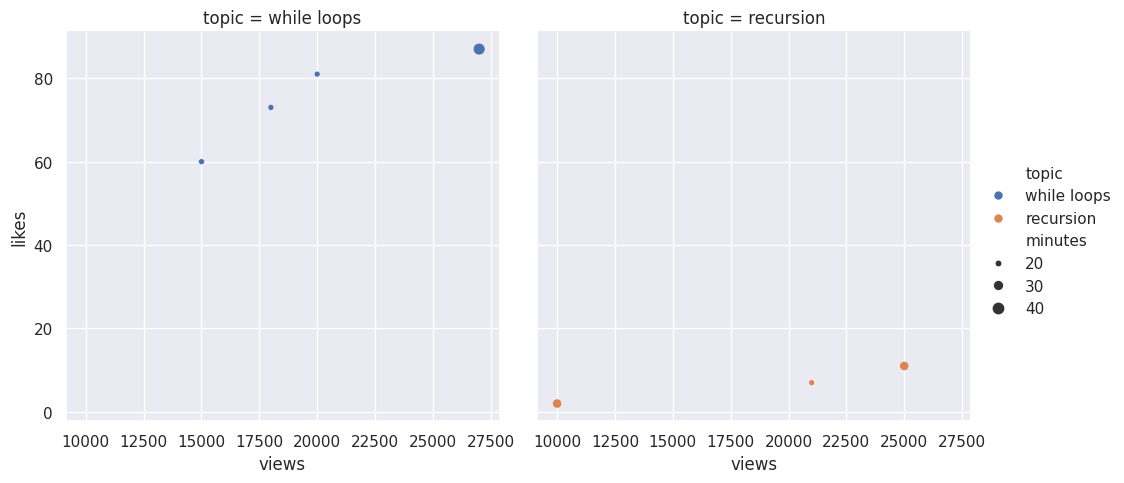

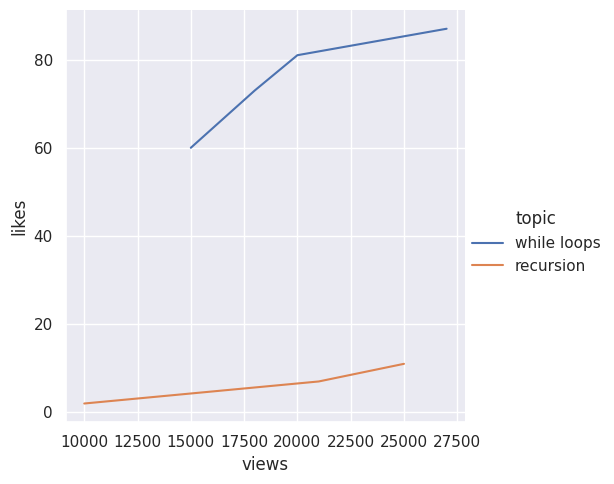

In [58]:
import seaborn as sns
from data_utils import convert_columns_to_int

sns.set_theme()

example_data: dict[str, list[str]] = {"minutes": ["20", "20", "30", "20", "20", "30", "40"], 
                                      "views": ["15000", "20000", "10000", "18000", "21000", "25000", "27000"], 
                                      "likes": ["60", "81", "2", "73", "7", "11", "87"],
                                      "topic": ["while loops", "while loops", "recursion", "while loops", "recursion", "recursion", "while loops"]}

example_data_converted: dict[str, list[str | int]] = convert_columns_to_int(example_data, ["minutes", "views", "likes"])

sns.relplot(data=example_data_converted, kind="scatter",
            x="views", y="likes", size="minutes", 
            col="topic", hue="topic")

sns.relplot(data=example_data_converted, kind="line", 
            x="views", y="likes", 
            hue="topic")

Let's go through this line-by-line.

`import seaborn as sns`

First, we import the `seaborn` package, using the `as` keyword to give it a quicker nickname `sns`. This will enable us to use any classes or functions defined in the `seaborn` package by using the prefix `sns.` and then our desired function or class name. This will look like we are calling methods with `sns` as our object, which is technically true, but think of `sns` as a module with a whole bunch of code in it that we are using bits of, not as an object with attributes that you are looking to access and modify.

`sns.set_theme()`

Then we call the `set_theme` function with no argument to give all of the plots we will create the default theme. There are [more themes](https://seaborn.pydata.org/tutorial/aesthetics.html#seaborn-figure-styles) available!

`example_data: dict[str, list[str]] = ...`

Now we create some example data to plot, with the exact same types and shape as the column-wise data that comes out of `columnar`.

`example_data_converted: dict[str, list[str | int]] = ...`

Then we use the provided starter function `convert_columns_to_int` to convert some of our columns to have the data type `int`, storing the result in a dictionary with keys of type `str` and values of type `list[str | int]`. This type that uses `|` is the same concept as what was used in class for representing a linked list (a `Node` having a `next` attribute of type `Node | None`). This means that the values of this dictionary are lists with each value in the list being of type `str` or `int`. Union types are especially useful when handling data of mixed types, which is true of the survey data you are working with (e.g. Majors are `str`s, Likert data (responses on a scale of 1-7) is of type `int`). Another starter function, `get_keys` also uses Union types to handle a wide variety of inputs. Its input is of type `dict[str, list[str]] | dict[str, list[int]] | dict[str, list[str]] | dict[str, list[str | int]] | dict[str, int] | dict[str, str]` to handle the different possibilities of what the value's type could be for various shapes (e.g. row-based, column-based) of data that we give to this function. Please note that `head`, `select`, `concat`, and `count` don't accept Union types as input, so try to only use the `convert_columns_to_int` as a last step before you make a plot. It is totally fine if your custom function(s) take Union types as input though!

Now on the final two lines we plot, first a scatterplot, then a line plot, using the `relplot` function with a few different parameters to customize our figure each time. 
- `data` - This is where you input your data dictionary.
- `kind` - Customizes the kind of plot you'll get from `relplot`. Possible values: "scatter", "line"
- `x`, `y` - Use these to define the data that will be on your x and y axes, using your column names as the arguments.
- `size` (Optional) - Use this to define the size of your dots for the scatterplot or the width of the lines for the lineplot relative to a column's data, using the column's name as the argument.
- `col` (Optional) - Use this to split your figure into multiple plots based on the values in a column, using the column's name as the argument.
- `hue` (Optional) - Use this to define the color of your dots or lines for the lineplot relative to a column's data, using the column's name as the argument.

#### Further Exploration

Seaborn uses a hierarchical structure for its plotting functions, for example `scatterplot` and `lineplot` are contained under `relplot`, or relational plot, like we just saw. The `kind` parameter is used to select which type of plot you would like. The other two overarching functions are `displot` for distribution plots and `catplot` for categorical plots. See the relevant documentation [here](https://seaborn.pydata.org/tutorial/function_overview.html#figure-level-vs-axes-level-functions) for a visual of what kind of plots are contained within each category.

Now it is time for you to explore the documentation further. These pages will contain a lot of information, and it is important to remember that they are intended to be comprehensive, but you do not have to use all of the possible features and parameters!
- `relplot` [link](https://seaborn.pydata.org/generated/seaborn.relplot.html)
- `displot` [link](https://seaborn.pydata.org/generated/seaborn.displot.html)
- `catplot` [link](http://seaborn.pydata.org/generated/seaborn.catplot.html)

As was mentioned in the rubric, you will be expected to create at least three visualizations of your data using `seaborn`, with at least one of them being outside of the two example plots shown previously. Use the documentation links above to find out what other types of plot(s) you would like to make!

While brainstorming and considering what ideas you have the data for, begin to consider what kind of visualizations would work best to support your analysis, and come back to these documentation links when you are ready to make some plots. Outside of these links, you are free to explore all of the functions and objects available in the `seaborn` package at this link: https://seaborn.pydata.org/api.html

#### Optional Customization

*Read this section if you are interested in further customizing your figures, but feel free to skip to Part 1!*

If you are curious about the object returned by these plotting functions, `sns.FacetGrid`, look here: [docs link](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html). This documentation page begins by showing all of the possible parameters for its `__init__` method, then some examples of its usage, and finally its methods and attributes. `seaborn` does most of the customization for you so it is optional but encouraged to explore these methods and attributes.

If you read any of the provided documentation pages thoroughly enough, you may start to see mentions of another library called `matplotlib`, such as the methods and attributes of `sns.FacetGrid`. `seaborn` is based on `matplotlib`, and it offers more customization options but is more complex to use than `seaborn`. Certain properties you might expect of a `sns.FacetGrid` object have to work with underlying `matplotlib` objects and attributes to be set, such as creating a title for your figure (see the example below). Attributes like title that have to be accessed in this way are listed [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html#matplotlib.axes.Axes:~:text=and%20False%20otherwise.-,**kwargs,-Other%20optional%20keyword) in the documentation for `matplotlib`.

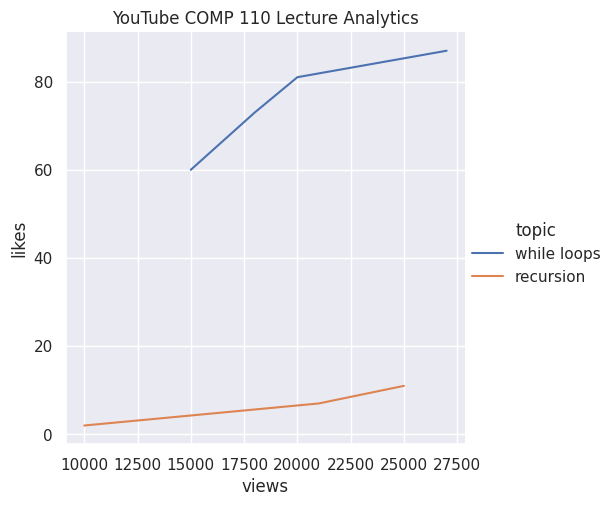

In [59]:
lineplot: sns.FacetGrid = sns.relplot(data=example_data_converted, kind="line", 
            x="views", y="likes", 
            hue="topic")

lineplot.set(title="YouTube COMP 110 Lecture Analytics")

## Part 1: Analysis for Continuous Improvement

Continuous Improvement embraces a belief there is _always room to make things better_. It is a mindset and process we value and practice in this course. In this assignment, you are able to practice continuous improvement and contribute to the design ideas of the course.

### Brainstorming Ideas

Reflect on your personal experiences and observations in COMP110 and **brainstorm modifications to the course that _create value_ beyond its current design**. When brainstorming, try not to be critical of the ideas you come up with regarding scale, stakeholders impacted, or for any other reasons. In the markdown cell below, brainstorm 3 to 5 ideas you think would create value for you.

Each brainstormed idea should state a. the suggested change or addition, b. what the expected value created, and c. which specific stakeholders would benefit.  If helpful, expand on the following template "The course should (state idea here) because it will (state value created here) for (insert stakeholders here)."

Example A: "The course should use only examples from psychology experiments because it will be more relevant for students who are psychology majors."

Example B: "The course should not have post-lesson questions because they are not useful for most students in the class."

### Part 1.1: Creative Ideation

1. This course should have in-class question opportunities like "Poll Everywhere." Many chemistry and biology students take this course, and are familiar with this method of learning and in-class participation.
2. Instead of relying on office hours, this course should have a recitation where students can practice and ask questions. This would be more effective than sitting in lecture, trying to solve problems instead of learning material. Many people don't use office hours due to a lack of uniform free time. A recitation, would provide a standard meeting time for review.
3. Preparing class materials/software like VSCode and Docker Desktop should be done together in class, as opposed to before class. This is because many students have no prior or very minimal coding experience.
4. Because it is hard to go to office hours, COMP 110 canvas/website should have a discussion box to assist with learning code. It owuld also help students work together.
5. An extended deadline for post-class lesson assignments would be more effective then doing them the day of class. 

#### Connecting with Available Data

As a reminder, each row represents an individual survey response, and each column has a description which can be found on the project write-up here: <https://26s-comp110.github.io/exercises/ex09_data_analysis.html>

Review the list of available data and identify which one of your ideas _does not_, or is _least likely to_, have relevant data to support the analysis of your idea to create value. In the box below, identify which of your ideas lacks data and suggest how we might be able to collect this data in the future. One aspect of _continuous improvement_ is trying to avoid "tunnel vision" where possible improvements are not considered because there is no data available to analyze it. Identifying new data sources can unlock improvements!

### Part 1.2: Identifying Missing Data

1. Idea without sufficient data to analyze:

2. Suggestion for how to collect data to support this idea in the future: 

#### Choosing an Idea to Analyze

Consider those of your ideas which _do_ seem likely to have relevant data to analyze. If none of your ideas do, spend a few minutes and brainstorm another idea or two with the added connection of data available on hand and add those ideas to your brainstormed ideas list.

Select the one idea which you believe is _most valuable_ to analyze relative to the others and has data to support the analysis of. In the markdown cell for Part 3 below, identify the idea you are exploring and articulate why you believe it is most valuable (e.g. widest impact, biggest opportunity for improvement, simplest change for significant improvement, and so on).

### Part 1.3: Choosing Your Analysis

1. Idea to analyze with available data:

2. This idea is more valuable than the others brainstormed because: 


#### Your Analysis

Before you begin analysis, a reminder that we do not expect the data to support everyone's ideas and you can complete this exercise for full credit even if the data does not clearly support your suggestion or even completely refutes it. What we are looking for is a logical attempt to explore the data using the techniques you have learned up until now in a way that _either_ supports, refutes, or does not have a clear result and then to reflect on your findings after the analysis.

Using the utility functions you created for the previous exercise, you will continue with your analysis in the following part. Before you begin, refer to the rubric on the technical expectations of this section in the exercise write-up.

In this section, you are expected to interleave code and markdown cells such that for each step of your analysis you are starting with an English description of what you are planning to do next in a markdown cell, followed by a Python cell that performs that step of the analysis.

Additionally, you will be producing charts or visualizations as part of your analysis via the Python package `seaborn`. Refer to the previous section on python packages and data visualization for more information on how to use this package and to the rubric for what will be required.

### Part 1.4: Analysis

Make sure to import your custom helper function in the code block below!

# Should there be a COMP110 Recitation?

 
### In this analysis we investigate whether the data suggests that a COMP110 reciation should exist or not. We will look to the amount of people that attend office hours and how effective each person thinks office hours is in their learning experience.

# Data Reading Function

 In this python cell, we import our main data reading functions. For read_csv_rows, it allows us to convert data from csv to a list of dictionaries our code can digest. For get_keys, it extracts the column heads from a single-rowed dictionary to give us the keys/column headers from the csv file. For column_values, it iterates through the list of dictionaries and pulls out every value asscoiated with one specific column header and puts them into a list of stirngs. For columnar, it transforms the entire dataset from a row-based structure to a column-based structure. Together all of these functions will form a digstible dataset which aligns with our code.

In [60]:
from data_utils import read_csv_rows, get_keys, column_values, columnar

DATA_FILE_DIRECTORY: str = "data/"
DATA_FILE_NAMES: list[str] = ["survey_izzi.csv", "survey_alyssa.csv"]
DATA_FILE_NAME_IZZI: str = f"{DATA_FILE_DIRECTORY}{DATA_FILE_NAMES[0]}"
DATA_FILE_NAME_ALYSSA: str = f"{DATA_FILE_DIRECTORY}{DATA_FILE_NAMES[1]}"

data_rows1: list[dict[str, str]] = read_csv_rows(DATA_FILE_NAME_ALYSSA)

if len(data_rows1) == 0:
    print("Go implement read_csv_rows in data_utils.py")
    print("Be sure to save your work before re-evaluating this cell!")
else:
    print(f"Data File Read: {DATA_FILE_NAME_ALYSSA}")
    print(f"{len(data_rows1)} rows")
    print(f"{len(get_keys(data_rows1[0]))} columns")
    print(f"Columns names: {get_keys(data_rows1[0])}")

data_rows2: list[dict[str, str]] = read_csv_rows(DATA_FILE_NAME_IZZI)

if len(data_rows2) == 0:
    print("Go implement read_csv_rows in data_utils.py")
    print("Be sure to save your work before re-evaluating this cell!")
else:
    print(f"Data File Read: {DATA_FILE_NAME_IZZI}")
    print(f"{len(data_rows2)} rows")
    print(f"{len(get_keys(data_rows2[0]))} columns")
    print(f"Columns names: {get_keys(data_rows2[0])}")

years1: list[str] = column_values(data_rows1, "year")

if len(years1) == 0:
    print("Complete your implementation of column_values in data_utils.py")
    print(
        "Be sure to follow the guidelines above and save your work before re-evaluating!"
    )
else:
    print(f"Column 'year' has {len(years1)} values.")
    print("The first five values are:")
    for i in range(5):
        print(years1[i])

years2: list[str] = column_values(data_rows2, "year")

if len(years2) == 0:
    print("Complete your implementation of column_values in data_utils.py")
    print(
        "Be sure to follow the guidelines above and save your work before re-evaluating!"
    )
else:
    print(f"Column 'year' has {len(years2)} values.")
    print("The first five values are:")
    for i in range(5):
        print(years2[i])

data_cols1: dict[str, list[str]] = columnar(data_rows1)

if len(get_keys(data_cols1)) == 0:
    print("Complete your implementation of columnar in data_utils.py")
    print(
        "Be sure to follow the guidelines above and save your work before re-evaluating!"
    )
else:
    print(f"{len(get_keys(data_cols1))} columns")
    print(f"{len(data_cols1['year'])} rows")
    print(f"Columns names: {get_keys(data_cols1)}")

data_cols2: dict[str, list[str]] = columnar(data_rows2)

if len(get_keys(data_cols2)) == 0:
    print("Complete your implementation of columnar in data_utils.py")
    print(
        "Be sure to follow the guidelines above and save your work before re-evaluating!"
    )
else:
    print(f"{len(get_keys(data_cols2))} columns")
    print(f"{len(data_cols2['year'])} rows")
    print(f"Columns names: {get_keys(data_cols2)}")


Data File Read: data/survey_alyssa.csv
230 rows
44 columns
Columns names: ['row', 'year', 'unc_status', 'transfer', 'comp_major', 'major', 'prereqs', 'prior_exp', 'ap_principles', 'ap_a', 'other_comp', 'prior_time', 'languages', 'hours_online_social', 'hours_online_work', 'tech_best_interests', 'apps_accessible', 'identity_my_interaction', 'id_interact_with_me', 'interested_connections', 'social_issues', 'research_biases', 'researchers_unbiased', 'empirical_data', 'cs_objective', 'algorithms_objective', 'tech_impact', 'pre_lecture_videos', 'add_livestream', 'own_notes', 'own_examples', 'oh_visits', 'ls_effective', 'lsqs_effective', 'programming_effective', 'qz_effective', 'oh_effective', 'tutoring_effective', 'pace', 'difficulty', 'understanding', 'interesting', 'valuable', 'would_recommend']
Data File Read: data/survey_izzi.csv
534 rows
44 columns
Columns names: ['row', 'year', 'unc_status', 'transfer', 'comp_major', 'major', 'prereqs', 'prior_exp', 'ap_principles', 'ap_a', 'other_com

## Combining data from both classes.

In this cell, we will take datasets from Alyssa and Izzi's classes and create one dataset, using our concat function.

In [61]:
from data_utils import concat

table1: dict[str, list[str]] = columnar(read_csv_rows(DATA_FILE_NAME_ALYSSA))
table2: dict[str,list[str]] = columnar(read_csv_rows(DATA_FILE_NAME_IZZI))

combined: dict[str, list[str]] = concat(table1, table2)


tabulate(head(combined, 10), get_keys(combined), "html")

row,year,unc_status,transfer,comp_major,major,prereqs,prior_exp,ap_principles,ap_a,other_comp,prior_time,languages,hours_online_social,hours_online_work,tech_best_interests,apps_accessible,identity_my_interaction,id_interact_with_me,interested_connections,social_issues,research_biases,researchers_unbiased,empirical_data,cs_objective,algorithms_objective,tech_impact,pre_lecture_videos,add_livestream,own_notes,own_examples,oh_visits,ls_effective,lsqs_effective,programming_effective,qz_effective,oh_effective,tutoring_effective,pace,difficulty,understanding,interesting,valuable,would_recommend
1,28,Junior,No,No,Applied Physical Sciences,"MATH 129P, MATH 130, MATH 231, MATH 232, MATH 233, MATH 381",1-2 years,Yes,No,UNC,None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,4,3,5,6,6,7,6,6,2,4,6,6,3,2,7,5,1,7,7,7,7,,,4,3,6,6,6,7
2,28,Junior,No,No,Applied Sciences,"MATH 129P, MATH 231, MATH 232, MATH 233, MATH 381, STOR 155",1-2 years,No,No,High school course (IB or other),None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,5,6,6,6,5,7,7,3,3,3,3,5,3,5,7,5,0,4,7,7,4,,,4,1,6,6,6,6
3,28,Sophomore,No,No,Biology,"MATH 231, MATH 232, MATH 233, STOR 155",None to less than one month!,,,,,,3 to 5 hours,0 to 2 hours,6,6,5,5,5,6,6,6,5,6,6,6,5,5,6,6,1,5,6,6,6,,,4,3,6,5,6,6
4,28,Sophomore,No,No,Biology,"MATH 130, MATH 231, STOR 155",None to less than one month!,,,,,,5 to 10 hours,5 to 10 hours,6,7,7,7,3,7,7,7,6,7,6,6,7,7,6,6,2,5,5,4,6,,6,6,6,3,5,6,3
5,28,Senior,No,No,Biology,"MATH 129P, MATH 231, MATH 232, MATH 233",None to less than one month!,,,,,,10+ hours,5 to 10 hours,1,7,7,7,7,7,7,6,4,5,5,5,4,6,5,3,0,4,5,5,1,,,2,3,5,4,5,6
6,29,Freshman,No,No,Biology,"MATH 129P, MATH 231, STOR 155",2-6 months,No,No,Another college or community college,None to less than one month!,"Python, HTML / CSS",3 to 5 hours,5 to 10 hours,1,7,2,2,7,7,7,2,1,6,7,6,2,1,7,6,0,2,6,7,7,,,4,4,6,7,7,7
7,28,Sophomore,No,No,Biology,"MATH 130, MATH 231",None to less than one month!,,,,,,0 to 2 hours,3 to 5 hours,3,7,5,6,7,7,6,3,4,5,4,5,6,7,7,6,1,7,7,7,7,5,,5,4,2,6,7,7
8,29,Freshman,No,No,Biology,"MATH 130, MATH 231",None to less than one month!,,,,,,3 to 5 hours,3 to 5 hours,4,6,6,6,3,1,5,5,3,5,6,5,7,7,5,3,1,7,7,7,7,7,7,4,4,5,6,6,7
9,29,Sophomore,No,No,Biology,"MATH 129P, MATH 231",None to less than one month!,,,,,,5 to 10 hours,3 to 5 hours,5,6,7,7,5,6,4,2,3,4,5,5,6,4,4,5,0,4,4,6,6,,,5,3,5,7,5,5
10,27,Senior,No,No,Biology,"MATH 231, STOR 155",2-6 months,No,No,High school course (IB or other),None to less than one month!,Python,3 to 5 hours,3 to 5 hours,4,4,1,1,2,3,6,4,3,2,6,6,5,5,6,5,0,5,4,7,7,,,5,4,4,4,4,4


## Office Hours Attendance and Effectiveness

In this cell, we will make a new table using our select function. It will allow us to isolate the data on rows, difficulty, and office hours attendance and effectiveness. It is important to make the functions within the list strings using quotation marks.

We use tabulate to ensure the table was created correctly.

In [62]:
from data_utils import select, head

names: list[str] = ["row", "oh_visits", "oh_effective", "difficulty"]

finalized_data: dict[str, list[str]] = select(combined, names)

tabulate(head(finalized_data, 10), get_keys(finalized_data), "html")

row,oh_visits,oh_effective,difficulty
1,1,,3
2,0,,1
3,1,,3
4,2,,6
5,0,,3
6,0,,4
7,1,5,4
8,1,7,4
9,0,,3
10,0,,4


## Isolating students that attend office hours

For our first anaylsis, we will look at the amount of total students, and students that attend office hours. First we count total number of students by finding the length of the column rows. To do so, we must make a new dict() using the column oh_visits (for total student number) and the str "used_oh" for students that attended office hours. This will require to make and import a new function which counts the students whose oh_visits != 0, meaning they visited office hours at least once. 

In [63]:
from data_utils import count_attendance

total_students: int = len(finalized_data["row"])

print(total_students)

attended_oh: int = count_attendance(finalized_data["oh_visits"])

print(attended_oh)


764
446


## Analysis 1: Total number of Students vs. Students that have attended office hours

We will use catplot from seaborn to create a categorical bar graph comparing the two values.


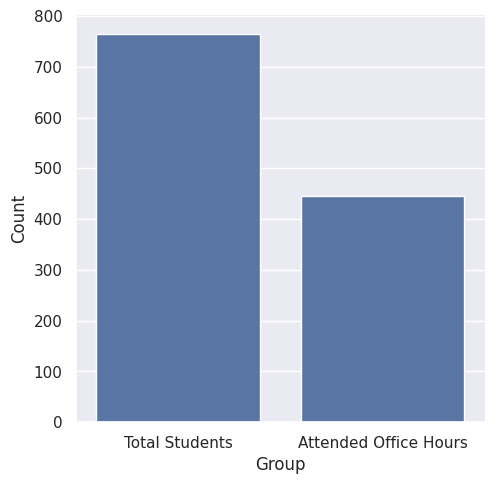

In [64]:
import seaborn as sns

attendance_data: dict[str, list[str | int]] = {"Group": ["Total Students", "Attended Office Hours"], "Count":[total_students, attended_oh]}
# makes a digestable code for catplot to read

figure_1 = sns.catplot(data = attendance_data, x="Group", y="Count", kind="bar")

## How effective do students feel office hours is?

To determine how effective students feel office hours is, we can call on the count function to sort the effectiveness ratings of office hours by the number of students that selected that choice. This well help us understand how much students feel the benifit from office hours.

In [65]:
from data_utils import count

effective: dict[str, int] = count(finalized_data["oh_effective"])

print(effective)

{'': 399, '5': 97, '7': 71, '6': 66, '4': 86, '3': 23, '1': 10, '2': 12}


## Analysis 2: Student perception of office hours effectiveness

This bar chart shows the distirbution of students that use office hours and how they perceive office hours as an effective resource in COMP 110.

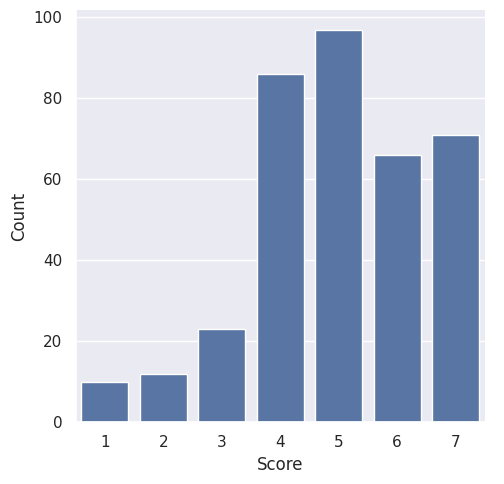

In [66]:
effective_data: dict[str, list[str | int]] = {"Score": list(effective.keys()), "Count":list(effective.values())}

figure_2 = sns.catplot(data = effective_data, x="Score", y="Count", kind="bar", order=[1, 2, 3, 4, 5, 6, 7])
# 399 people left the question blank.

## Do students that find the class difficult attend office hours?

By looking into whether students that find the class difficult attend office hours, we can better understand if students try to use office hours as a resource when the class is difficult. In other words, if students find the class difficult and don't attend office hours, adding a recitiation might also benifit the course.

## Analysis 3: To what extent do students find class to be hard, and do these students attend office hours?

This bar graph sorts the degree of difficult students find the class from 1-7. Within each category of diffulty, it further seperates the total number of students in that category into the amount of office hours visits those students take.

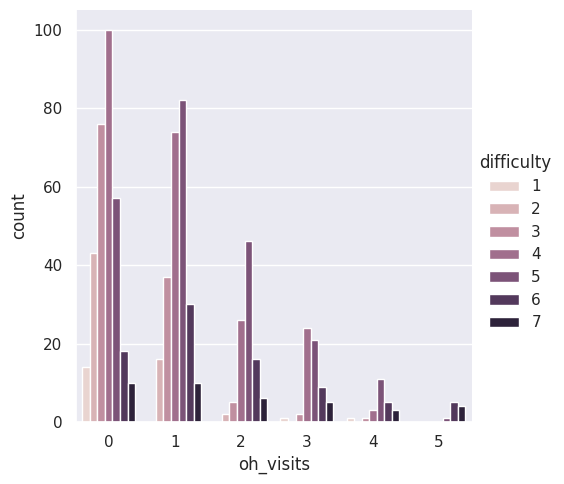

In [67]:
difficulty_oh_data_converted: dict[str, list[str | int]] = convert_columns_to_int(finalized_data, ["difficulty", "oh_visits"])

sns.catplot(
    data=difficulty_oh_data_converted ,
    hue="difficulty",
    x="oh_visits",
    kind="count"
)

### Part 1.5: Conclusion



#### Conclusion

 

### Analysis 1

We know the total number of students in 764 that completed the survey. According to our bar chart, of that 764 students, around 465 attend office hours. From this graph we can conclude that while a majority of students attend office hours, there is a large amount of students that do not. If there were a recitation, then COMP110 instructors could ensure that all students were able to receive extra help in the class. This analysis lays the groundwork for the idea that recitation would positively effect more students than just the ones that are able to attend office hours. A way that we can improve this figure is by adding a new category of students that did not attend office hours so that we can visualize both sides clearly.

 

### Analysis 2

Of the 465 students that attended office hours, this figure tells us how many of them deemed it to be effective. The score values range from 1-7, with 1 being the lowest effectiveness rating and 7 being the highest effectiveness rating. The overwhelming majority of responses are in the range of 4-7, meaning that of the students that used office hours as a resource, the majority found it effective. A way to make the data from this graph viable is to run a statistical analysis between the bars on the graph to prove the visual observation that the majority of students who use office hours find it effective.

 

### Analysis 3

In this analysis we investigated how the number of office hours visits and the degree of difficulty of the class compare. Despite a low sample size, the students that went to office hours the most appear to find the class more difficult. On the other hand it appears that despite the amount of office hours visits from 0-4, students view the difficulty of COMP110 in what appears to be a normal distribution. Essentially, office hours does not affect how students view the difficulty of the class. Again there would need to be statistical tests and analyses to determine how normal this distribution is an reaffirm the assumption we have just drawn. Something important to note, additionally, is that students might go to office hours because they find the class difficult. Office hours may help them find the class less difficult, but the data is not explicit. Therefore, we can compare it to our second analysis.

 

### In Summary

Our initial argument asserted that many students can't take advantage of office hours due to time conflict and in place there should be a recitation to provide a practice/tutoring environment where students can ask more questions on a uniform basis. Our analyses confirmed that a large amount of students do not attend office hours, but out of the students who do attend it, they find it effective in learning. In our third analysis, the amount of time a student visits office hours does not appear to change how they view the difficulty of the class. This potentially refutes our argument that students need office hours, if it does not change their perception on the difficulty of class. However, analysis 2 tell us that the people who use office hours, find it effective, for the majority. Additionally, students may find the class more difficult and want to use office hours, meaning office hours is unrelated to the difficult of the class. We would need to look at grades in order to see if office hours is an indicator of success in the class.

 

From this, we can conclude that office hours, it is an effective tool, but is not used by all students. In order to provide all students with this tool, we believe a recitation would be the best solution. We recognize that our third figure implies office hours does not correlate to a perception of class difficulty. This means that recitation may not be effective in making the class easier for students. However, this is correlation and not a causation, while figure 2 directly tells us students feel office hours is effective. Additionally, pushback from adopting a recitation in class would certainly occur because students don't want to spend more time in class. Yet, we argue that this time in class will help them learn more effectively and ensure that every student uses the same resources.

 

## Part 2: Presenting Your Results

Follow the instructions [linked here](https://26s-comp110.github.io/projects/personal-site.html) to set up your website, and refer to the rubric in the project write-up for what will be required!

Once you are finished, put the links (for each partner) to each of your project pages below. We will only be grading the first link given according to the rubric, but make sure the second link works and looks similar to the first.

First link: 

Second link: 